# Pair trading  con todos los pares

       z-scores 
            Choice of beta calculacion: regresion / kalman filter
            Choice of averaging:
                  Using moving average window / exponential mean averaging / kalman filter  

In [22]:
%load_ext autoreload
%autoreload 2  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import numpy as np, os, copy
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from time import time
from itertools import permutations
import sys; sys.path.insert(0, '../')
from read_data import load_ts
import statistics
#import arbitrage as ar
from cointegracion import zscore_moving_win,inversion

import utils
import sys; sys.path.insert(0, '../')


La clase cnf se utiliza para definir todos los parametros de configuracion del modelo

Se debe definir directorio donde se encuentran los datos

In [16]:
class cnf:
    pathdat='../dat/' # directorio de los datos
    tipo='asset' # 'asset', 'return', 'log_return', 'log'
    Ntraining = 1000 # length of the training period
    beta_win=61   #21
    zscore_win=31 #11
    sigma_co=1.5 # thresold to buy
    sigma_ve=0.1 # thresold to sell
    nmax=-1 #-1 #  10 # number of companies to generate the pairs (-1 all, 10 for testing)
    nsel=10 # 100 # 10 # number of best pairs to select
    linver_betaweight=0
    industry=['oil']
    fname=f'tmp/all_pair_' # fig filename
    shorten=0

In [17]:
# load data
day,date,price,company,volume = load_ts(sectors=cnf.industry, pathdat=cnf.pathdat)


Hago las simulaciones de todos los pares con los assets seleccionados

In [ ]:
metrics = statistics.all_pairs_stats(price[:,:cnf.Ntraining],company,'asset')
idx_selected_pairs = np.argsort(metrics.pvalue)[:cnf.nsel]


In [18]:
idx_selected_pairs = [3298, 3594, 1090, 3279, 1125,  404,  951,  782, 2393, 1731] # selected pairs by pvalue
indices_permutations = list(permutations(range(price.shape[0]), 2))
idx_selected_assets = [indices_permutations[i] for i in idx_selected_pairs]

assets_l = [  [price[i,cnf.Ntraining:],
                  price[j,cnf.Ntraining:]]
                  for i,j in idx_selected_assets ]
print(company.shape)

company_l = [  [company[i],company[j]] for i,j in idx_selected_assets ]

# se realiza el procedimiento para cada uno de los pares
res_l=[]
for i, (x, y) in enumerate(assets_l):
    res_d = inversion(x,y,cnf)
    res_d['company']=company_l[i]        
    res_l.append( res_d )
        
res = utils.Results(res_l) # paso a objetos


(61,)


Selecciono los pares con los mejores resultados

Calculo metricas de estacionaridad del spread para los pares seleccionados

In [28]:
metrics = statistics.stats(res.assets,'log')

Funciones usadas para graficacion. 

In [19]:
def vertical_bar(axs,compras,ccompras):
    ''' Plot the entrada y salida de posiciones '''
    start_indices, end_indices= utils.calc_startend(compras[:,None])
    start_cindices, end_cindices= utils.calc_startend(ccompras[:,None])

    indices=np.arange(compras.shape[0])
    for ax in axs:
        for start, end in zip(start_indices[0], end_indices[0]):
            ax.axvspan(indices[start], indices[end], alpha=0.3, color='green')
        for start, end in zip(start_cindices[0], end_cindices[0]):
            ax.axvspan(indices[start], indices[end], alpha=0.3, color='red')


In [20]:
def plot_capital_single(j,res0,fname):
    nt=res0.spread.shape[1]
    res = copy.deepcopy(res0) 
    res.reorder(j) # select the pair
    
    figfile=cnf.fname+f'capital{j}.png'
    
    fig, ax = plt.subplots(3,1,figsize=(7,7))
    ax[0].plot(res.zscore)
    ax[0].set_title('Z-score')
    

    for ivar in range(res.corto.shape[-1]):
        ax[1].plot(res.corto[:,ivar],label='corto '+res.company[ivar])
    ax[1].legend()

    for ivar in range(res.corto.shape[-1]):
        ax[2].plot(res.largo[:,ivar],label='largo '+res.company[ivar])
    ax[2].legend()

    vertical_bar(ax,res.compras,res.ccompras)

    plt.tight_layout()
    fig.savefig(figfile)
    plt.close()


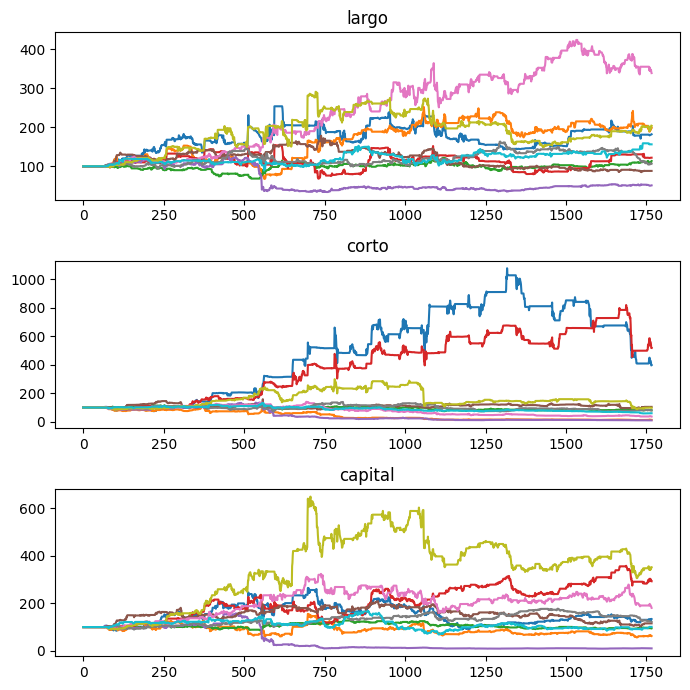

In [21]:
figfile=cnf.fname+'capital.png'
fig, ax = plt.subplots(3,1,figsize=(7,7))
ax[0].plot(res.largo.mean(-1).T)
ax[0].set(title='largo')
ax[1].plot(res.corto.mean(-1).T)
ax[1].set(title='corto')
ax[2].plot(res.capital.T)
ax[2].set(title='capital')
plt.tight_layout()
#fig.savefig(figfile)
plt.show()
plt.close()

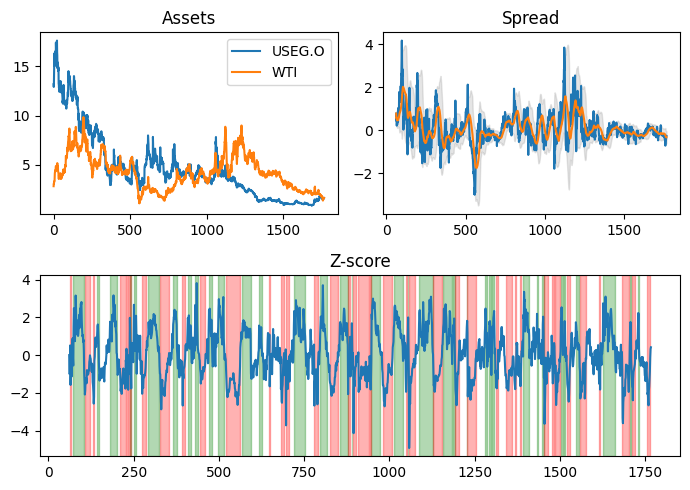

In [22]:
def plot_zscore(j,res0,fname):
    nt=res0.spread.shape[1]

    res = copy.deepcopy(res0) 
    res.reorder(j) # select the pair

    figfile=fname+f'zscore{j}.png'
    fig = plt.figure(figsize=(7, 5))

    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(res.assets[0],label=res.company[0])
    ax1.plot(res.assets[1],label=res.company[1])
    ax1.legend()
    ax1.set_title('Assets')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(range(nt),res.spread)
    ax2.plot(range(nt),res.spread_mean)
    ax2.fill_between(range(nt), res.spread_mean - 1.96* res.spread_std,
                     res.spread_mean +1.96* res.spread_std,color='gray', alpha=0.2)
    ax2.set_title('Spread')

    ax3 = fig.add_subplot(gs[1, :])
    ax3.plot(res.zscore)
    ax3.set_title('Z-score')

    vertical_bar([ax3],res.compras,res.ccompras)
    
    plt.tight_layout()
    #fig.savefig(figfile)
    plt.show()
    plt.close()


plot_zscore(0,res,cnf.fname)


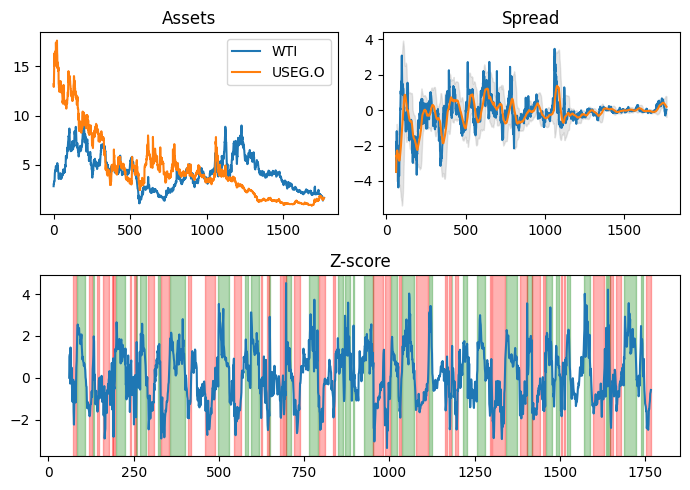

In [23]:
plot_zscore(1,res,cnf.fname)

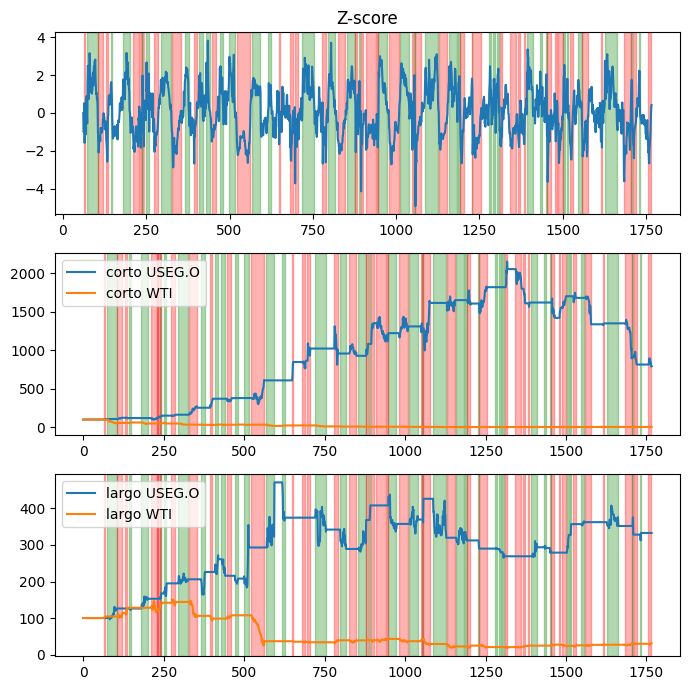

In [24]:
def plot_capital_single(j,res0,fname):
    nt=res0.spread.shape[1]
    res = copy.deepcopy(res0) 
    res.reorder(j) # select the pair
    
    figfile=cnf.fname+f'capital{j}.png'
    
    fig, ax = plt.subplots(3,1,figsize=(7,7))
    ax[0].plot(res.zscore)
    ax[0].set_title('Z-score')
    

    for ivar in range(res.corto.shape[-1]):
        ax[1].plot(res.corto[:,ivar],label='corto '+res.company[ivar])
    ax[1].legend()

    for ivar in range(res.corto.shape[-1]):
        ax[2].plot(res.largo[:,ivar],label='largo '+res.company[ivar])
    ax[2].legend()

    vertical_bar(ax,res.compras,res.ccompras)

    plt.tight_layout()
    #fig.savefig(figfile)
    plt.show()
    plt.close()
plot_capital_single(0,res,cnf.fname)

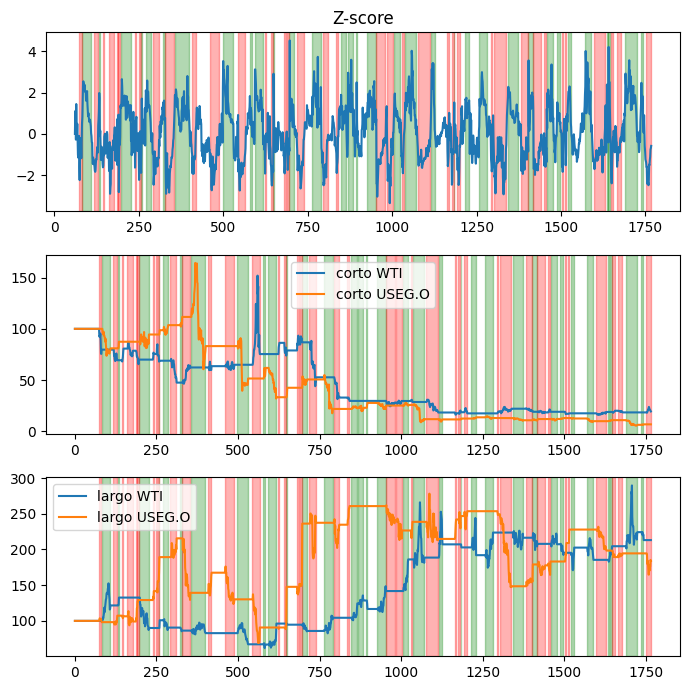

In [25]:
plot_capital_single(1,res,cnf.fname)


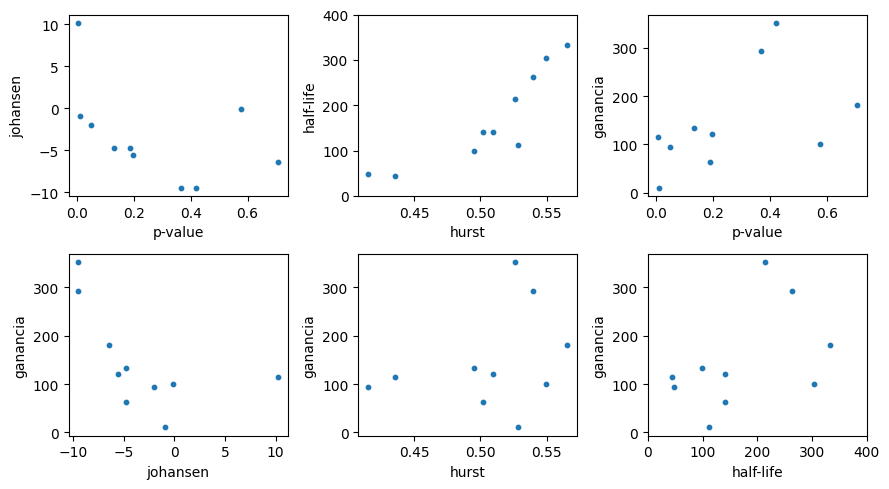

In [29]:
figfile=cnf.fname+f'scatters.png'
fig, ax = plt.subplots(2,3,figsize=(9,5))
ax[0,0].scatter(metrics.pvalue,metrics.johansen,s=10)
ax[0,0].set(xlabel='p-value',ylabel='johansen')
ax[0,1].scatter(metrics.hurst,metrics.half_life,s=10)
ax[0,1].set(xlabel='hurst',ylabel='half-life',ylim=[0,400])
ax[0,2].scatter(metrics.pvalue,res.capital[:,-1],s=10)
ax[0,2].set(xlabel='p-value',ylabel='ganancia')

ax[1,0].scatter(metrics.johansen,res.capital[:,-1],s=10)
ax[1,0].set(xlabel='johansen',ylabel='ganancia')
ax[1,1].scatter(metrics.hurst,res.capital[:,-1],s=10)
ax[1,1].set(xlabel='hurst',ylabel='ganancia')
ax[1,2].scatter(metrics.half_life,res.capital[:,-1],s=10)
ax[1,2].set(xlabel='half-life',ylabel='ganancia',xlim=[0,400])

plt.tight_layout()
#fig.savefig(figfile)
plt.show()
plt.close()
